# Run MOSAIKS model on basemaps imagery

In [ ]:
# Run MOSAIKS model on basemaps imagery
import os
import pickle
import sys
import time
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from einops import rearrange
from torch.utils.data import DataLoader
from torchgeo.models import RCF
from tqdm import tqdm

sys.path.append("../utils")

import config
import data_utils

In [ ]:
dataset = data_utils.VisualBasemapDataset(
    root_dir=config.clipped_dir,
    transform=None,
    resize=None,
    specific_dir=None,
    clipped=True,
    verbosity=0,
)


dataloader = DataLoader(
    dataset=dataset,
    batch_size=100,
    shuffle=False,
    collate_fn=lambda x: x,
    num_workers=20,
)

mosaiks = RCF(
    in_channels=3,
    features=4000,
    kernel_size=3,
    bias=-1,
    seed=42,
    mode="gaussian",
    dataset=None,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mosaiks.eval().to(device)

# Initialize data structures
unique_ids = []
basemap_ids = []
x_all = np.zeros((len(dataset), 4000), dtype=np.float32)

i = 0
tic = time.time()

with torch.inference_mode():
    for batch in dataloader:
        for image in batch:
            unique_id = image["unique_id"]

            if i % 100 == 0:
                print(
                    f"{i:,}/{len(dataset):,} -- {i / len(dataset) * 100:0.2f}% -- {time.time() - tic:0.2f} seconds"
                )
                tic = time.time()

            image_tensor = image["image"].to(device, non_blocking=True)
            basemap_id = image["basemap_id"]

            feats = mosaiks(image_tensor).cpu().numpy()

            x_all[i] = feats
            unique_ids.append(unique_id)
            basemap_ids.append(basemap_id)
            i += 1

features_df = pd.DataFrame(x_all, index=unique_ids)
features_df = features_df.add_prefix("X_").reset_index()
features_df.rename(columns={"index": "unique_id"}, inplace=True)
features_df["basemap_id"] = basemap_ids
filename = os.path.join(config.data_dwir, "features", "features_mosaiks_4000.feather")
features_df.to_feather(filename)


In [ ]:
embeddings = []
for batch in dataloader:
    b, t = batch.shape[0], batch.shape[1]
    with torch.inference_mode():
        # Run MOSAIKS across all imagery indepedently
        x = rearrange(batch, "b t c h w -> (b t) c h w")
        emb = mosaiks(x)

        embeddings.append(emb)


100

In [5]:
for batch in dataloader:
    b, t = batch.shape[0], batch.shape[1]
    print(b)

AttributeError: 'list' object has no attribute 'shape'

In [15]:
batch[1]

{'image': tensor([[[0.0863, 0.1059, 0.1294,  ..., 0.1294, 0.1333, 0.1529],
          [0.0824, 0.0941, 0.1255,  ..., 0.1020, 0.1176, 0.1451],
          [0.0980, 0.1020, 0.1294,  ..., 0.0941, 0.1059, 0.1216],
          ...,
          [0.1333, 0.1569, 0.1412,  ..., 0.1098, 0.1020, 0.1059],
          [0.1137, 0.1255, 0.1294,  ..., 0.1020, 0.0941, 0.0941],
          [0.1255, 0.1294, 0.1451,  ..., 0.0863, 0.0824, 0.1020]],
 
         [[0.0980, 0.1255, 0.1412,  ..., 0.1294, 0.1333, 0.1451],
          [0.1020, 0.1176, 0.1412,  ..., 0.1176, 0.1294, 0.1490],
          [0.1098, 0.1216, 0.1412,  ..., 0.1216, 0.1294, 0.1333],
          ...,
          [0.1373, 0.1569, 0.1451,  ..., 0.1098, 0.0980, 0.1020],
          [0.1176, 0.1333, 0.1451,  ..., 0.1059, 0.0902, 0.0941],
          [0.1255, 0.1373, 0.1569,  ..., 0.0902, 0.0824, 0.1020]],
 
         [[0.0392, 0.0588, 0.0706,  ..., 0.0627, 0.0667, 0.0745],
          [0.0314, 0.0392, 0.0627,  ..., 0.0471, 0.0627, 0.0784],
          [0.0471, 0.0471, 0.06

In [ ]:
import os
import pickle
import sys
import time
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from torchgeo.models import RCF
from tqdm import tqdm

sys.path.append("../utils")

import config
import data_utils
import planet_api
import planet_utils

In [2]:
config.clipped_dir_2019

'/data/wildfire_prep/clipped_basemaps/clipped_basemaps_2019'

In [ ]:
# dataset = data_utils.VisualBasemapDataset(
#         root_dir = config.basemap_dir,
#         transform = None,
#         resize = None,
#         specific_dir = None, # "global_monthly_2019_09_mosaic",
#         clipped = False,
#         verbosity = 0,

# )
dataset = data_utils.VisualBasemapDataset(
    root_dir=config.clipped_dir_2019,
    transform=None,
    resize=None,
    specific_dir=None,  # "global_monthly_2019_09_mosaic",
    clipped=True,
    verbosity=0,
)
# dataset[0]['image']

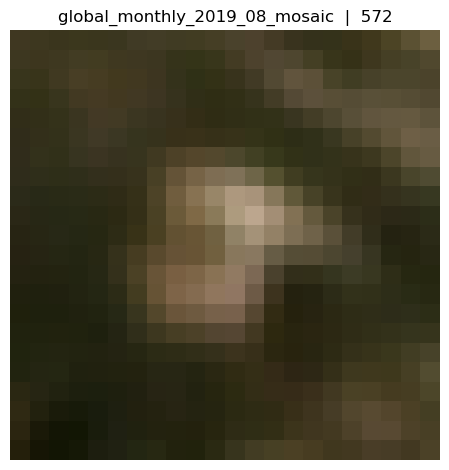

In [ ]:
sample = dataset[0]  # already returns a dict
img = sample["image"]  # shape: (C, H, W) – float32 in [0, 1]
h, w = img.shape[1:]

img_np = img.permute(1, 2, 0).cpu().numpy()  # (H, W, C)

# --- plot --------------------------------------------------------------------
plt.figure()  # rough pixel-for-pixel sizing
plt.imshow(img_np)
plt.title(f"{sample['basemap_id']}  |  {sample['unique_id']}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
dataloader = DataLoader(
    dataset=dataset,
    batch_size=100,
    shuffle=False,
    collate_fn=lambda x: x,
    num_workers=20,
)
dataloader

In [6]:
mosaiks = RCF(
    in_channels=3,
    features=4000,
    kernel_size=3,
    bias=-1,
    seed=42,
    mode="gaussian",
    dataset=None,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mosaiks.eval().to(device)

RCF()

### Featurize clipped imagery

In [ ]:
# Files to store data
processed_ids_file = f"{config.data_dir}/features/processed_ids.pkl"
results_file = f"{config.data_dir}/features/image_features.pkl"

# Load previously processed image IDs if the file exists
if os.path.exists(processed_ids_file):
    with open(processed_ids_file, "rb") as f:
        processed_ids = pickle.load(f)
else:
    processed_ids = set()

# Initialize data structures
unique_ids = []
basemap_ids = []
x_all = np.zeros((len(dataset), 4000), dtype=float)

i = 0
tic = time.time()
save_frequency = 500  # Save every 500 images

for batch in dataloader:
    for image in batch:
        unique_id = image["unique_id"]

        # Skip if this image has already been processed
        if unique_id in processed_ids:
            continue

        if i % 100 == 0:
            print(
                f"{i:,}/{len(dataset):,} -- {i / len(dataset) * 100:0.2f}% -- {time.time() - tic:0.2f} seconds"
            )
            tic = time.time()

        with torch.inference_mode():
            image_tensor = image["image"].to(device)
            basemap_id = image["basemap_id"]

            feats = mosaiks(image_tensor).cpu().numpy()

            x_all[i] = feats
            unique_ids.append(unique_id)
            basemap_ids.append(basemap_id)
            processed_ids.add(unique_id)
            i += 1

        # # Periodically save progress
        # if i % save_frequency == 0:
        #     # Save the processed IDs
        #     with open(processed_ids_file, "wb") as f:
        #         pickle.dump(processed_ids, f)

        #     # Save intermediate results
        #     with open(results_file, "wb") as f:
        #         pickle.dump({
        #             "unique_ids": unique_ids,
        #             "basemap_ids": basemap_ids,
        #             "x_all": x_all[:i]  # Save only the filled portion
        #         }, f)

        #     print(f"Saved progress after processing {i} images")

# # Trim the unused portion of the array
# if i < len(x_all):
#     x_all = x_all[:i]

# # Final save
# with open(processed_ids_file, "wb") as f:
#     pickle.dump(processed_ids, f)

# with open(results_file, "wb") as f:
#     pickle.dump({
#         "unique_ids": unique_ids,
#         "basemap_ids": basemap_ids,
#         "x_all": x_all
#     }, f)

# print(f"Processing complete. Saved {i} images.")

0/14,827 -- 0.00% -- 8.35 seconds
100/14,827 -- 0.67% -- 30.65 seconds
200/14,827 -- 1.35% -- 31.36 seconds
300/14,827 -- 2.02% -- 31.29 seconds
400/14,827 -- 2.70% -- 31.15 seconds
Saved progress after processing 500 images
500/14,827 -- 3.37% -- 32.15 seconds


In [ ]:
features_df = pd.DataFrame(x_all, index=unique_ids)
features_df = features_df.add_prefix("X_").reset_index()
features_df.rename(columns={"index": "unique_id"}, inplace=True)
features_df["basemap_id"] = basemap_ids
filename = os.path.join(config.data_dwir, "features", "features_mosaiks_4000.feather")
features_df.to_feather(filename)